In [26]:
%pip install scikit-learn matplotlib -q

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    classification_report

)

warnings.filterwarnings("ignore")

In [29]:
# =========================================================
# DIRECTORY CONFIGURATION
# =========================================================

ROOT_DIR = "/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan"

RESULT_DIR = os.path.join(

    ROOT_DIR,

    "data",

    "results"

)

EVAL_DIR = os.path.join(

    ROOT_DIR,

    "data",

    "eval"

)

VIS_DIR = os.path.join(

    ROOT_DIR,

    "visualizations"

)

os.makedirs(

    EVAL_DIR,

    exist_ok=True

)

os.makedirs(

    VIS_DIR,

    exist_ok=True

)

print("Result Directory :")
print(RESULT_DIR)

print()

print("Evaluation Directory :")
print(EVAL_DIR)

print()

print("Visualization Directory :")
print(VIS_DIR)

Result Directory :
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/results

Evaluation Directory :
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval

Visualization Directory :
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/visualizations


In [30]:
# =========================================================
# LOGGING CONFIGURATION
# =========================================================

import logging

LOG_DIR = os.path.join(

    ROOT_DIR,

    "logs"

)

os.makedirs(

    LOG_DIR,

    exist_ok=True

)

LOG_PATH = os.path.join(

    LOG_DIR,

    "evaluation.log"

)

for handler in logging.root.handlers[:]:

    logging.root.removeHandler(handler)

logging.basicConfig(

    filename=LOG_PATH,

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    filemode="w"

)

logging.info(
    "===== NOTEBOOK 05 STARTED ====="
)

print(LOG_PATH)

/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/logs/evaluation.log


In [31]:
# =========================================================
# LOAD FILES
# =========================================================

prediction_file = os.path.join(

    RESULT_DIR,

    "predictions.csv"

)

retain_file = os.path.join(

    RESULT_DIR,

    "case_base_retained.csv"

)

pred_df = pd.read_csv(

    prediction_file

)

retain_df = pd.read_csv(

    retain_file

)

print("Prediction Shape :")
print(pred_df.shape)

print()

print("Retain Shape :")
print(retain_df.shape)

logging.info(

    f"Prediction File : {pred_df.shape}"

)

logging.info(

    f"Retain File : {retain_df.shape}"

)

Prediction Shape :
(30, 6)

Retain Shape :
(30, 6)


In [32]:
# =========================================================
# VALIDATE PREDICTION FILE
# =========================================================

required_prediction = [

    "query_id",

    "query",

    "actual_solution",

    "predicted_solution",

    "top_5_case_ids"

]

missing_prediction = [

    col

    for col in required_prediction

    if col not in pred_df.columns

]

if len(missing_prediction) > 0:

    raise ValueError(

        f"Kolom predictions.csv tidak ditemukan : {missing_prediction}"

    )

print("Prediction Validation Passed")

Prediction Validation Passed


In [33]:
# =========================================================
# VALIDATE RETAIN FILE
# =========================================================

required_retain = [

    "case_id",

    "retrieval_topic",

    "amar_putusan",

    "dakwaan",

    "clean_text",

    "combined_text"

]

missing_retain = [

    col

    for col in required_retain

    if col not in retain_df.columns

]

if len(missing_retain) > 0:

    raise ValueError(

        f"Kolom case_base_retained.csv tidak ditemukan : {missing_retain}"

    )

print("Retain Validation Passed")

Retain Validation Passed


In [34]:
# =========================================================
# PREVIEW DATA
# =========================================================

display(
    pred_df.head()
)

display(
    retain_df.head()
)

print()

print("Jumlah Prediksi :", len(pred_df))

print("Jumlah Case Base :", len(retain_df))

,query_id,query,actual_solution,predicted_solution,top_5_case_ids,top_5_similarity
0,1,Bom Ikan,"mengadili,“Mereka yang melakukan, yang menyuru...",mengadili” dan ketentuan Pasal 197 ayat (1) bu...,case_020;case_006;case_017;case_030;case_010,5.8571;5.7245;5.5293;5.3957;5.2741
1,2,Trawl,MENGADILI SENDIRI:1.Menyatakan Terdakwa Rizal ...,mengadili Pengadilan NegeriPalembang dikarenak...,case_003;case_013;case_022;case_005;case_012,1.3978;0.9208;0.9184;0.8699;0.7138
2,3,Trawl,mengadili Pengadilan NegeriPalembang dikarenak...,mengadili Pengadilan NegeriPalembang dikarenak...,case_003;case_013;case_022;case_005;case_012,1.3978;0.9208;0.9184;0.8699;0.7138
3,4,Tanpa SIPI,mengadili Perkara Pidana dalam tingkat banding...,mengadili Perkara Pidana dalam tingkat banding...,case_004;case_021;case_016;case_009;case_028,4.7305;4.1934;4.1745;4.1713;4.0907
4,5,Trawl,mengadili sendiri perkara inidengan amar putus...,mengadili Pengadilan NegeriPalembang dikarenak...,case_003;case_013;case_022;case_005;case_012,1.3978;0.9208;0.9184;0.8699;0.7138


,case_id,retrieval_topic,amar_putusan,dakwaan,clean_text,combined_text
0,case_001,Bom Ikan,"mengadili,“Mereka yang melakukan, yang menyuru...",didakwa:KESATU :BahwaTerdakwaISOPIAN binRABBIL...,bom ikan pada hari senin tanggal 02 nopember 2...,Bom Ikan pada hari senin tanggal 02 nopember 2...
1,case_002,Trawl,MENGADILI SENDIRI:1.Menyatakan Terdakwa Rizal ...,didakwa dengan dakwaan sebagai berikut:Dakwaan...,trawl bahwa terdakwa melanggar pasal 98 undang...,Trawl bahwa terdakwa melanggar pasal 98 undang...
2,case_003,Trawl,mengadili Pengadilan NegeriPalembang dikarenak...,didakwa dengan dakwaan sebagai berikut :Bahwa ...,trawl pada hari kamis tanggal 4 februari 2016 ...,"Trawl pada hari kamis,tanggal 4 februari 2016 ..."
3,case_004,Tanpa SIPI,mengadili Perkara Pidana dalam tingkat banding...,didakwa sebagai berikut : Kesatu: Bahwa terdak...,tanpa sipi bahwa terdakwa sugiyantoro als giya...,Tanpa SIPI bahwa terdakwa sugiyantoro als. giy...
4,case_005,Trawl,mengadili sendiri perkara inidengan amar putus...,didakwa dengan dakwaan sebagai berikut:-Kesatu...,trawl bahwa terdakwa mengakuibelumpernah dihuk...,Trawl bahwa terdakwa mengakuibelumpernah dihuk...



Jumlah Prediksi : 30
Jumlah Case Base : 30


In [35]:
# =========================================================
# RETRIEVAL EVALUATION FUNCTION
# =========================================================

def eval_retrieval(predictions, k=5):

    y_true = []

    y_pred = []

    hit_count = 0

    for _, row in predictions.iterrows():

        actual_case = f"case_{int(row['query_id']):03d}"

        retrieved_cases = str(

            row["top_5_case_ids"]

        ).split(";")[:k]

        if actual_case in retrieved_cases:

            y_true.append(1)

            y_pred.append(1)

            hit_count += 1

        else:

            y_true.append(1)

            y_pred.append(0)

    accuracy = accuracy_score(

        y_true,

        y_pred

    )

    precision = precision_score(

        y_true,

        y_pred,

        zero_division=0

    )

    recall = recall_score(

        y_true,

        y_pred,

        zero_division=0

    )

    f1 = f1_score(

        y_true,

        y_pred,

        zero_division=0

    )

    hit5 = hit_count / len(predictions)

    return {

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-Score": f1,

        "Hit@5": hit5

    }

In [36]:
# =========================================================
# RUN RETRIEVAL EVALUATION
# =========================================================

retrieval_result = eval_retrieval(

    pred_df,

    k=5

)

retrieval_metrics = pd.DataFrame({

    "Metric":

    retrieval_result.keys(),

    "Value":

    retrieval_result.values()

})

display(

    retrieval_metrics

)

,Metric,Value
0,Accuracy,0.633333
1,Precision,1.000000
2,Recall,0.633333
3,F1-Score,0.775510
4,Hit@5,0.633333


In [37]:
# =========================================================
# SAVE RETRIEVAL METRICS
# =========================================================

retrieval_metrics_file = os.path.join(

    EVAL_DIR,

    "retrieval_metrics.csv"

)

retrieval_metrics.to_csv(

    retrieval_metrics_file,

    index=False,

    encoding="utf-8-sig"

)

print(

    "Saved :"

)

print(

    retrieval_metrics_file

)

logging.info(

    f"Retrieval Metrics Saved : {retrieval_metrics_file}"

)

Saved :
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/retrieval_metrics.csv


In [38]:
# =========================================================
# RETRIEVAL SUMMARY
# =========================================================

print("="*60)

print("RETRIEVAL EVALUATION")

print("="*60)

for _, row in retrieval_metrics.iterrows():

    print(

        f"{row['Metric']} : {row['Value']:.4f}"

    )

RETRIEVAL EVALUATION
Accuracy : 0.6333
Precision : 1.0000
Recall : 0.6333
F1-Score : 0.7755
Hit@5 : 0.6333


In [39]:
# =========================================================
# PREPARE PREDICTION LABELS
# =========================================================

actual_labels = pred_df[

    "actual_solution"

].astype(str)

predicted_labels = pred_df[

    "predicted_solution"

].astype(str)

print("Jumlah Actual :", len(actual_labels))
print("Jumlah Predicted :", len(predicted_labels))

Jumlah Actual : 30
Jumlah Predicted : 30


In [40]:
# =========================================================
# PREDICTION EVALUATION
# =========================================================

accuracy = accuracy_score(

    actual_labels,

    predicted_labels

)

precision = precision_score(

    actual_labels,

    predicted_labels,

    average="weighted",

    zero_division=0

)

recall = recall_score(

    actual_labels,

    predicted_labels,

    average="weighted",

    zero_division=0

)

f1 = f1_score(

    actual_labels,

    predicted_labels,

    average="weighted",

    zero_division=0

)

prediction_metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

display(
    prediction_metrics
)

,Metric,Value
0,Accuracy,0.200000
1,Precision,0.073611
2,Recall,0.200000
3,F1-Score,0.094444


In [41]:
# =========================================================
# SAVE PREDICTION METRICS
# =========================================================

prediction_metrics_file = os.path.join(

    EVAL_DIR,

    "prediction_metrics.csv"

)

prediction_metrics.to_csv(

    prediction_metrics_file,

    index=False,

    encoding="utf-8-sig"

)

print("Saved :")
print(prediction_metrics_file)

logging.info(

    f"Prediction Metrics Saved : {prediction_metrics_file}"

)

Saved :
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/prediction_metrics.csv


In [42]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

report = classification_report(

    actual_labels,

    predicted_labels,

    output_dict=True,

    zero_division=0

)

report_df = pd.DataFrame(

    report

).transpose()

display(
    report_df
)

,precision,recall,f1-score,support
"MENGADILI SENDIRI:1.Menyatakan Terdakwa Rizal tersebut di atas terbukti secara sah danmeyakinkan bersalah melakukan tindak pidana “Nakhoda KapalPerikanan yang tidak memiliki surat persetujuan berlayar” sebagaimanadalam dakwaan alternatif kedua;2.Menjatuhkan pidana kepada Terdakwa dengan pidana penjara selama10 (sepuluh) bulan dan denda sejumlah Rp150.000.000,00 (seratuslima puluh juta rupiah) dengan ketentuan apabila denda tersebut tidakdibayar, diganti dengan pidana kurungan selama 1 (satu) bulan;3.Menetapkan masa penangkapan dan penahanan yang telah dijalanioleh Terdakwa dikurangkan seluruhnya dari pidana yang dijatuhkan;4.Menetapkan Terdakwa tetap di tahan;5.Menetapkan barang bukti berupa:-1 (satu) unit Kapal ikan KM. Sentral Rezeki II GT. 30;-1 (satu) buah kemudi Utama;-4 (empat ) set Jaring Trawl, 1 (satu) unit GPS Navigator Model AE 32Nomor Seri 20732100601C;-1 (satu) unit GPS echo sounder Merk MMEC Ploter; -1 (satu) unit Radio Transmiter IC.2100 FM Transceiver Merk ICON; -1 (satu) unit Kompas Magnet;-Dokumen Kapal berupa: -1 (satu) lembar Asli SIPI dari Dinas Kelautan dan PerikananProvinsi Sumatera Utara Nomor 523.3a/0556-J/08.4.0.1/VIII/2016,tanggal 22 Juli 2016; Nomor 102 K/Pid.Sus/2018 : Halaman 6 -1 (satu) lembar Asli SIUP dari Dinas Kelautan dan PerikananProvinsi Sumatera Utara Nomor 523.3a/0545-J/IUP/2015, berlakutanggal 7 September 2015 sampai dengan 6 September 2035;-1 (satu) lembar asli Pas Besar 17 Oktober 2013;-1 (satu) lembar asli Sertifikat Kelaikan dan Pengawakan KapalPenangkap Ikan Nomor PK.001/26/11/KSOP.PC-16;-1 (satu) lembar asli Surat Ukur Dalam Negeri Nomor 2802/PPbtanggal 30 Desember 2011; -1 (satu) lembar asli SPB Nomor 373/09-VII/C/2016 tanggal 09 Juli2016;-1 (satu) lembar asli SLO Kapal Perikanan Nomor TBAIV.16.10112 tanggal 9 Juli 2016;-1 (satu) lembar asli SKK Nakhoda Kapal Nomor PK. 305/05/14/KSOP.Tba- 13 tanggal 26 Mei 2013 atas nama Rizal;-1(satu) lembar asli SKK KKM Kapal Nomor AL.405/14/ADP.Tba-05 tanggal 12 Agustus 2015 atas nama Parmohonan Harahap;Dikembalikan kepada pemiliknya yang berhak melalui Terdakwa;6.Membebankan biaya perkara kepada Terdakwa dalam kedua tingkatperadilan, yang dalam tingkat banding ini ditetapkan sebesarRp2.500,00 (dua ribu lima ratus rupiah);Membaca Akta Permohonan Kasasi Nomor 7/Akta-Kasasi.Pid.Sus-PRK/2017/PN.Mdn yang dibuat oleh Panitera pada Pengadilan Perikananpada Pengadilan Negeri Medan, yang menerangkan bahwa pada tanggal 17Oktober 2017, Penuntut Umum pada Kejaksaan Negeri Belawanmengajukan permohonan kasasi terhadap putusan Pengadilan Tinggi Medantersebut;Membaca Memori Kasasi tanggal 24 Oktober 2017 dari PenuntutUmum pada Kejaksaan Negeri Belawan tersebut sebagai Pemohon Kasasi,yang diterima di kanan pada PengadilanNegeri Medan pada tanggal 26 Oktober 2017;Membaca pula surat-surat lain yang bersangkutan; Nomor 102 K/Pid.Sus/2018 : Halaman 7 Menimbang bahwa putusan Pengadilan Tinggi Medan tersebut telahdiberitahukan kepada Penuntut Umum pada Kejaksaan Negeri Belawanpada tanggal 11 Oktober 2017 dan Penuntut Umum tersebut mengajukanpermohonan kasasi pada tanggal 17 Oktober 2017 serta memori kasasinyatelah diterima di kanan pada PengadilanNegeri Medan pada tanggal 26 Oktober 2017. Dengan demikian,permohonan kasasi beserta dengan alasan-alasannya telah diajukan dalamtenggang waktu dan dengan cara menurut undang-undang, oleh karena itupermohonan kasasi Penuntut Umum tersebut secara formal dapat diterima;Menimbang bahwa alasan kasasi yang diajukan PemohonKasasi/Penuntut Umum dalam memori kasasi selengkapnya termuat dalamberkas perkara;Menimbang bahwa terhadap alasan kasasi yang diajukanPemohon Kasasi/Penuntut Umum tersebut, Mahkamah Agungberpendapat sebagai berikut:Bahwa alasan kasasi Penuntut Umum dapat dibenarkan denganpertimbangan sebagai berikut:Bahwa Judex Facti (Pengadilan Tinggi) telah keliru dalammenerapkan hukum, mengadili tidak berdasarkan fakta hukum yangterungkap di persidangan dan mengadili tidak berdasarkan ket

In [43]:
# =========================================================
# SAVE CLASSIFICATION REPORT
# =========================================================

report_file = os.path.join(

    EVAL_DIR,

    "classification_report.csv"

)

report_df.to_csv(

    report_file,

    encoding="utf-8-sig"

)

print("Saved :")
print(report_file)

logging.info(

    f"Classification Report Saved : {report_file}"

)

Saved :
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/classification_report.csv


In [44]:
# =========================================================
# PREDICTION SUMMARY
# =========================================================

print("=" * 60)
print("PREDICTION EVALUATION")
print("=" * 60)

for _, row in prediction_metrics.iterrows():

    print(

        f"{row['Metric']} : {row['Value']:.4f}"

    )

PREDICTION EVALUATION
Accuracy : 0.2000
Precision : 0.0736
Recall : 0.2000
F1-Score : 0.0944


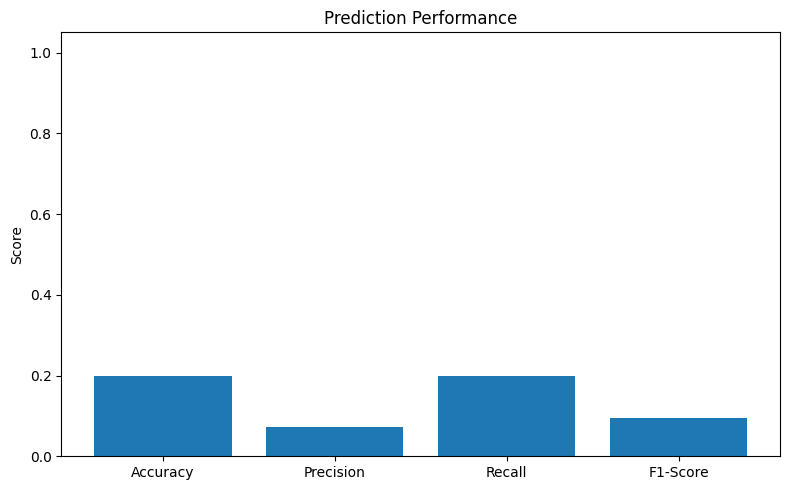

Saved :
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/visualizations/prediction_metrics.png


In [45]:
# =========================================================
# VISUALIZATION : PREDICTION METRICS
# =========================================================

plt.figure(

    figsize=(8,5)

)

plt.bar(

    prediction_metrics["Metric"],

    prediction_metrics["Value"]

)

plt.title(

    "Prediction Performance"

)

plt.ylabel(

    "Score"

)

plt.ylim(

    0,

    1.05

)

plt.tight_layout()

prediction_plot = os.path.join(

    VIS_DIR,

    "prediction_metrics.png"

)

plt.savefig(

    prediction_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("Saved :")

print(prediction_plot)

logging.info(

    f"Prediction Plot : {prediction_plot}"

)

logging.info(

    f"Retrieval Plot : {retrieval_plot}"

)

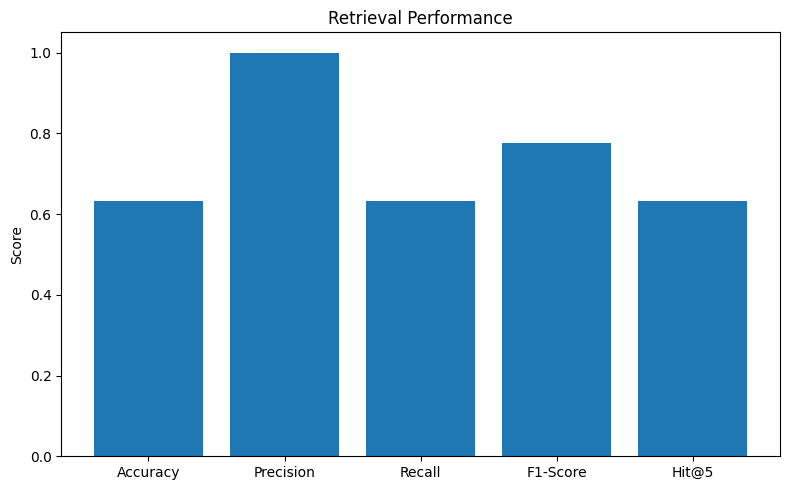

Saved :
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/visualizations/retrieval_metrics.png


In [46]:
# =========================================================
# VISUALIZATION : RETRIEVAL METRICS
# =========================================================

plt.figure(

    figsize=(8,5)

)

plt.bar(

    retrieval_metrics["Metric"],

    retrieval_metrics["Value"]

)

plt.title(

    "Retrieval Performance"

)

plt.ylabel(

    "Score"

)

plt.ylim(

    0,

    1.05

)

plt.tight_layout()

retrieval_plot = os.path.join(

    VIS_DIR,

    "retrieval_metrics.png"

)

plt.savefig(

    retrieval_plot,

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("Saved :")

print(retrieval_plot)

In [47]:
# =========================================================
# RETRIEVAL ERROR ANALYSIS
# =========================================================

retrieval_errors = []

for _, row in pred_df.iterrows():

    actual_case = f"case_{int(row['query_id']):03d}"

    retrieved_cases = str(

        row["top_5_case_ids"]

    ).split(";")

    if actual_case not in retrieved_cases:

        retrieval_errors.append({

            "query_id":

            row["query_id"],

            "query":

            row["query"],

            "actual_case":

            actual_case,

            "retrieved_cases":

            row["top_5_case_ids"]

        })

retrieval_errors = pd.DataFrame(

    retrieval_errors

)

print(

    "Jumlah Retrieval Error :",

    len(retrieval_errors)

)

display(

    retrieval_errors.head(10)

)

Jumlah Retrieval Error : 11


,query_id,query,actual_case,retrieved_cases
0,1,Bom Ikan,case_001,case_020;case_006;case_017;case_030;case_010
1,2,Trawl,case_002,case_003;case_013;case_022;case_005;case_012
2,11,Tanpa SIPI,case_011,case_004;case_021;case_016;case_009;case_028
3,18,Tanpa SIPI,case_018,case_004;case_021;case_016;case_009;case_028
4,19,Trawl,case_019,case_003;case_013;case_022;case_005;case_012
5,23,Perikanan Umum,case_023,case_008;case_012;case_030;case_015;case_021
6,24,Perikanan Umum,case_024,case_008;case_012;case_030;case_015;case_021
7,25,Bom Ikan,case_025,case_020;case_006;case_017;case_030;case_010
8,26,Tanpa SIPI,case_026,case_004;case_021;case_016;case_009;case_028
9,27,Bom Ikan,case_027,case_020;case_006;case_017;case_030;case_010


In [48]:
# =========================================================
# PREDICTION ERROR ANALYSIS
# =========================================================

prediction_errors = pred_df[

    pred_df["actual_solution"]

    !=

    pred_df["predicted_solution"]

].copy()

print(

    "Jumlah Prediction Error :",

    len(prediction_errors)

)

display(

    prediction_errors.head(10)

)

Jumlah Prediction Error : 24


,query_id,query,actual_solution,predicted_solution,top_5_case_ids,top_5_similarity
0,1,Bom Ikan,"mengadili,“Mereka yang melakukan, yang menyuru...",mengadili” dan ketentuan Pasal 197 ayat (1) bu...,case_020;case_006;case_017;case_030;case_010,5.8571;5.7245;5.5293;5.3957;5.2741
1,2,Trawl,MENGADILI SENDIRI:1.Menyatakan Terdakwa Rizal ...,mengadili Pengadilan NegeriPalembang dikarenak...,case_003;case_013;case_022;case_005;case_012,1.3978;0.9208;0.9184;0.8699;0.7138
4,5,Trawl,mengadili sendiri perkara inidengan amar putus...,mengadili Pengadilan NegeriPalembang dikarenak...,case_003;case_013;case_022;case_005;case_012,1.3978;0.9208;0.9184;0.8699;0.7138
5,6,Bom Ikan,mengadili perkara pidana dalam pengadilan ting...,mengadili” dan ketentuan Pasal 197 ayat (1) bu...,case_020;case_006;case_017;case_030;case_010,5.8571;5.7245;5.5293;5.3957;5.2741
8,9,Tanpa SIPI,mengadili perkara pidana dengan acara pemeriks...,mengadili Perkara Pidana dalam tingkat banding...,case_004;case_021;case_016;case_009;case_028,4.7305;4.1934;4.1745;4.1713;4.0907
9,10,Bom Ikan,mengadili perkara pidana denganacara pemeriksa...,mengadili” dan ketentuan Pasal 197 ayat (1) bu...,case_020;case_006;case_017;case_030;case_010,5.8571;5.7245;5.5293;5.3957;5.2741
10,11,Tanpa SIPI,mengadili perkara a quo sebab dalam sebuah kap...,mengadili Perkara Pidana dalam tingkat banding...,case_004;case_021;case_016;case_009;case_028,4.7305;4.1934;4.1745;4.1713;4.0907
11,12,Trawl,mengadili telah dilaksanakan menurut ketentuan...,mengadili Pengadilan NegeriPalembang dikarenak...,case_003;case_013;case_022;case_005;case_012,1.3978;0.9208;0.9184;0.8699;0.7138
12,13,Trawl,mengadili perkara pidana khusus pada tingkat k...,mengadili Pengadilan NegeriPalembang dikarenak...,case_003;case_013;case_022;case_005;case_012,1.3978;0.9208;0.9184;0.8699;0.7138
13,14,Kapal Asing,"mengadili perkara pidana pada tingkat Banding,...",Menyatakan Terdakwa MULIADI Alias MOLET terbuk...,case_015;case_014;case_029;case_019;case_022,3.6849;3.087;-2.3768;-2.7949;-2.8787


In [49]:
# =========================================================
# SAVE ERROR ANALYSIS
# =========================================================

retrieval_error_file = os.path.join(

    EVAL_DIR,

    "retrieval_errors.csv"

)

prediction_error_file = os.path.join(

    EVAL_DIR,

    "prediction_errors.csv"

)

retrieval_errors.to_csv(

    retrieval_error_file,

    index=False,

    encoding="utf-8-sig"

)

prediction_errors.to_csv(

    prediction_error_file,

    index=False,

    encoding="utf-8-sig"

)

print("Saved :")

print(retrieval_error_file)

print()

print(prediction_error_file)

logging.info(

    f"Retrieval Error File : {retrieval_error_file}"

)

logging.info(

    f"Prediction Error File : {prediction_error_file}"

)

Saved :
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/retrieval_errors.csv

/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/prediction_errors.csv


In [50]:
# =========================================================
# FINAL SUMMARY
# =========================================================

print("="*70)

print("MODEL EVALUATION SUMMARY")

print("="*70)

print()

print("Prediction Accuracy :",

      round(accuracy,4))

print("Prediction Precision :",

      round(precision,4))

print("Prediction Recall :",

      round(recall,4))

print("Prediction F1 Score :",

      round(f1,4))

print()

for _, row in retrieval_metrics.iterrows():

    print(

        f"{row['Metric']} : {row['Value']:.4f}"

    )

MODEL EVALUATION SUMMARY

Prediction Accuracy : 0.2
Prediction Precision : 0.0736
Prediction Recall : 0.2
Prediction F1 Score : 0.0944

Accuracy : 0.6333
Precision : 1.0000
Recall : 0.6333
F1-Score : 0.7755
Hit@5 : 0.6333


In [51]:
# =========================================================
# FINAL LOG
# =========================================================

logging.info(
    "===== NOTEBOOK 05 FINISHED ====="
)

logging.shutdown()

print("=" * 60)

print("NOTEBOOK 05 COMPLETED")

print("=" * 60)

print()

print("Evaluation Files")

print("-" * 60)

print(prediction_metrics_file)

print(retrieval_metrics_file)

print(report_file)

print(retrieval_error_file)

print(prediction_error_file)

print()

print("Visualization Files")

print("-" * 60)

print(prediction_plot)

print(retrieval_plot)

print()

print("Log File")

print("-" * 60)

print(LOG_PATH)

display(
    prediction_metrics
)

display(
    retrieval_metrics
)

NOTEBOOK 05 COMPLETED

Evaluation Files
------------------------------------------------------------
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/prediction_metrics.csv
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/retrieval_metrics.csv
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/classification_report.csv
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/retrieval_errors.csv
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/eval/prediction_errors.csv

Visualization Files
------------------------------------------------------------
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/visualizations/prediction_metrics.png
/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/visualizations/retrieval_metrics.png

Log File
------------------------------------------------------------
/content/drive/My

,Metric,Value
0,Accuracy,0.200000
1,Precision,0.073611
2,Recall,0.200000
3,F1-Score,0.094444


,Metric,Value
0,Accuracy,0.633333
1,Precision,1.000000
2,Recall,0.633333
3,F1-Score,0.775510
4,Hit@5,0.633333
